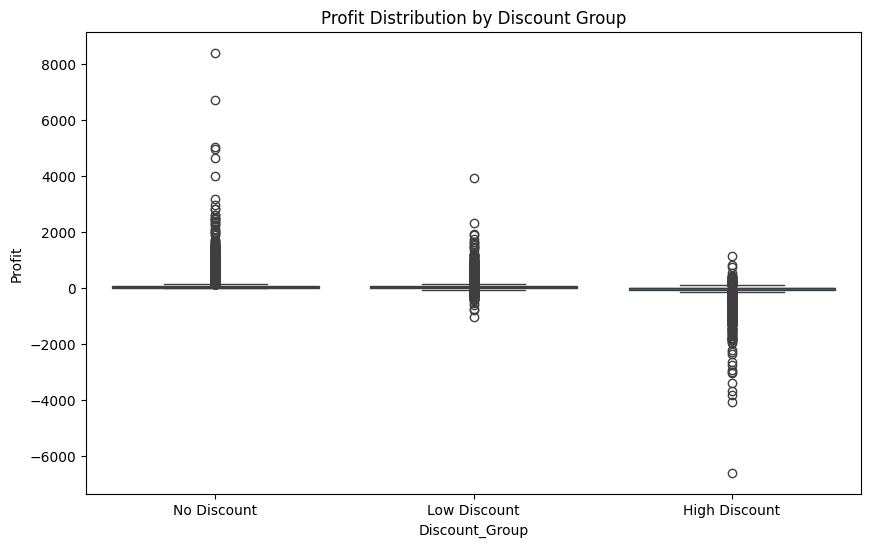

,Discount,Discount_Group,Profit
0,0.0,No Discount,762.1845
1,0.1,Low Discount,-288.7650
2,0.1,Low Discount,919.9710
3,0.1,Low Discount,-96.5400
4,0.0,No Discount,311.5200


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('/content/XX.xlsx')

df.columns = df.columns.str.strip()

def assign_group(discount):
    if discount == 0:
        return 'No Discount'
    elif discount <= 0.2:
        return 'Low Discount'
    else:
        return 'High Discount'

df['Discount_Group'] = df['Discount'].apply(assign_group)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Discount_Group', y='Profit', data=df)
plt.title('Profit Distribution by Discount Group')
plt.show()

df[['Discount', 'Discount_Group', 'Profit']].head()

In [13]:
import scipy.stats as stats

group_no = df[df['Discount_Group'] == 'No Discount']['Profit']
group_low = df[df['Discount_Group'] == 'Low Discount']['Profit']
group_high = df[df['Discount_Group'] == 'High Discount']['Profit']

f_stat, p_value = stats.f_oneway(group_no, group_low, group_high)

print(f"F-Statistiv=c: {f_stat:.2f}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
  print("\nConclusion: We reject the null hypothesis! Discounts have a substantial and statistically proven impact on profits.")
else:
  print("\nConclusion: We fail to reject the null hypothesis; the differences may be due to randomness.")

F-Statistiv=c: 2701.33
P-Value: 0.0

Conclusion: We reject the null hypothesis! Discounts have a substantial and statistically proven impact on profits.


In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df["Profit"],
                          groups=df["Discount_Group"],
                          alpha=0.05)
print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1       group2    meandiff p-adj  lower    upper   reject
------------------------------------------------------------------
High Discount Low Discount  118.612   0.0 113.4037 123.8203   True
High Discount  No Discount 132.9571   0.0  128.651 137.2632   True
 Low Discount  No Discount  14.3451   0.0   9.9863  18.7039   True
------------------------------------------------------------------
